In [ ]:
pip install ultralytics supervision opencv-python numpy tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.5 MB/s eta 0:00:00


In [ ]:
import urllib.request
import cv2
import numpy as np
from ultralytics import YOLO
import supervision as sv
from tqdm import tqdm

# --- 1. DOWNLOAD ASSETS ---
video_url = "https://media.roboflow.com/supervision/video-examples/people-walking.mp4"
video_path = "people-walking.mp4"
output_path = "output_flow_tracking.mp4"

print("Downloading video...")
urllib.request.urlretrieve(video_url, video_path)


model = YOLO("yolov8n.pt")
tracker = sv.ByteTrack()


video_info = sv.VideoInfo.from_video_path(video_path)

box_annotator = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_scale=0.5, text_thickness=1)

upper_line_y = int(video_info.height * 0.4)
lower_line_y = int(video_info.height * 0.6)


track_history = {}
in_count = 0
out_count = 0

heatmap_accum = np.zeros((video_info.height, video_info.width), dtype=np.float32)




Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# --- 4. VIDEO PROCESSING LOOP ---
print("Processing video frames...")
with sv.VideoSink(output_path, video_info) as sink:
    for frame in tqdm(sv.get_video_frames_generator(video_path), total=video_info.total_frames):

        # Detect humans (class 0 is 'person' in COCO dataset)
        results = model(frame, classes=[0], verbose=False)[0]
        detections = sv.Detections.from_ultralytics(results)

        # Update tracker with current detections to maintain IDs
        detections = tracker.update_with_detections(detections)

        labels = []

        for i in range(len(detections)):
            xyxy = detections.xyxy[i]
            tracker_id = detections.tracker_id[i]

            # Calculate the bounding box center (cx, cy)
            cx = int((xyxy[0] + xyxy[2]) / 2)
            cy = int((xyxy[1] + xyxy[3]) / 2)

            labels.append(f"#{tracker_id}")

            # --- HEATMAP ACCUMULATION ---#
            cv2.circle(heatmap_accum, (cx, cy), radius=20, color=1, thickness=-1)

            # --- COUNTING LOGIC ---#
            if tracker_id not in track_history:
                track_history[tracker_id] = cy
            else:
                prev_y = track_history[tracker_id]

                if prev_y < upper_line_y and cy >= upper_line_y:
                    in_count += 1

                if prev_y > lower_line_y and cy <= lower_line_y:
                    out_count += 1

                track_history[tracker_id] = cy

        frame = box_annotator.annotate(scene=frame, detections=detections)
        frame = label_annotator.annotate(scene=frame, detections=detections, labels=labels)

        cv2.line(frame, (0, upper_line_y), (video_info.width, upper_line_y), (0, 255, 0), 3)
        cv2.putText(frame, "Upper Line (IN Crossing)", (10, upper_line_y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        cv2.line(frame, (0, lower_line_y), (video_info.width, lower_line_y), (0, 0, 255), 3)
        cv2.putText(frame, "Lower Line (OUT Crossing)", (10, lower_line_y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

        cv2.rectangle(frame, (20, 20), (250, 110), (0, 0, 0), -1)
        cv2.putText(frame, f"IN : {in_count}", (30, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)
        cv2.putText(frame, f"OUT: {out_count}", (30, 100), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)

        sink.write_frame(frame)


Processing video frames...


100%|██████████| 341/341 [01:03<00:00,  5.37it/s]


In [ ]:
# --- 5. GENERATE FINAL HEATMAP ---
print("Generating final heatmap...")

heatmap_blurred = cv2.GaussianBlur(heatmap_accum, (99, 99), 0)

heatmap_norm = cv2.normalize(heatmap_blurred, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

heatmap_color = cv2.applyColorMap(heatmap_norm, cv2.COLORMAP_JET)

cv2.imwrite("final_heatmap.png", heatmap_color)

print("✅ Success! Check 'output_flow_tracking.mp4' and 'final_heatmap.png'")

Generating final heatmap...
✅ Success! Check 'output_flow_tracking.mp4' and 'final_heatmap.png'


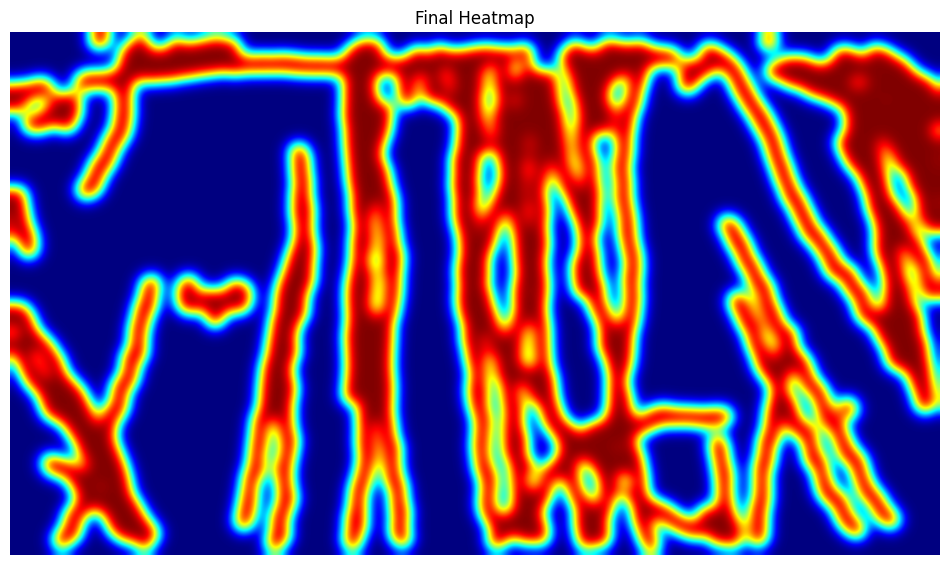

In [ ]:
import matplotlib.pyplot as plt
import cv2

img = cv2.imread('final_heatmap.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.title("Final Heatmap")
plt.show()